In [35]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_city
import matplotlib.pyplot as plt

In [36]:
# Функція для оракула
def deutsch_oracle(qc, case='balanced_x1'):
    """Додає оракул U_f до квантової схеми qc"""
    if case == 'constant_1':
        qc.x(1)      # константна f(x)=1
    elif case == 'balanced_x':
        qc.cx(0, 1)  # збалансована f(x)=x
    elif case == 'balanced_x1':
        qc.cx(0, 1)
        qc.x(1)      # збалансована f(x)=x⊕1
    # case 'constant_0' → нічого не робимо
    return qc

In [37]:
# Квантова схема для statevector (без класичних бітів)
qc_sv = QuantumCircuit(2)
qc_sv.x(1)           # другий кубіт у |1>
qc_sv.h([0, 1])      # Hadamard на обох кубітах
qc_sv = deutsch_oracle(qc_sv, case='balanced_x1')  # змінюй case для різних функцій
qc_sv.h(0)           # Hadamard на першому кубіті для інтерференції

# Отримуємо statevector без backend
state = Statevector.from_instruction(qc_sv)
print("Statevector:\n", state)

# Візуалізація statevector
plot_state_city(state)
plt.show()

Statevector:
 Statevector([-2.29934717e-17+0.j, -7.07106781e-01+0.j,  2.29934717e-17+0.j,
              7.07106781e-01+0.j],
            dims=(2, 2))


In [38]:
# Квантова схема для класичного вимірювання (QASM)

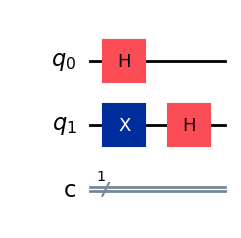

In [39]:
# Ініціалізація кубітів та класичного біту

# 2 кубіти (0 — вхідний, 1 — допоміжний) + 1 класичний біт для вимірювання
qc = QuantumCircuit(2, 1)

# Підготовка кубітів

qc.x(1)             # другий кубіт (допоміжний) у стан |1>
qc.h([0, 1])        # Hadamard на обох кубітах → створення суперпозиції всіх можливих входів
qc.draw("mpl")

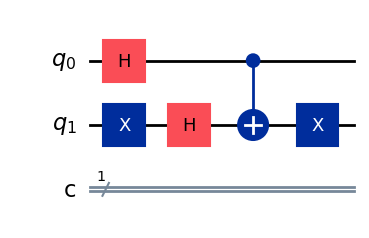

In [40]:
# Виклик оракула алгоритму Дойча

qc = deutsch_oracle(qc, case='balanced_x1')  # застосування U_f (оракула)
qc.draw("mpl")

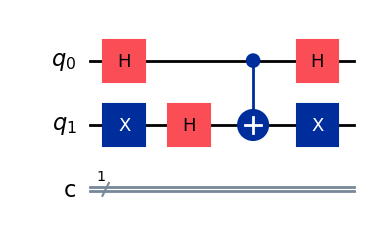

In [41]:
# Інтерференція та підготовка до вимірювання

qc.h(0)             # Hadamard на першому кубіті → інтерференція для визначення типу функції
qc.draw("mpl")

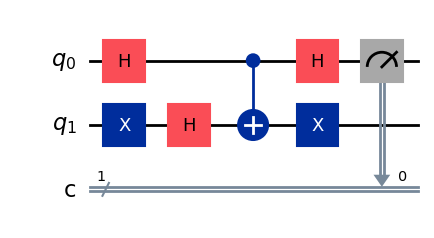

In [42]:
# Вимірювання

qc.measure(0, 0)    # вимірюємо перший кубіт і зберігаємо результат у класичний біт
qc.draw("mpl")

In [43]:
# Симуляція з вимірюванням (QASM)
backend_qasm = AerSimulator()
compiled_qasm = transpile(qc, backend_qasm)
job = backend_qasm.run(compiled_qasm, shots=1)
counts = job.result().get_counts()
print("Counts:", counts)

# Визначення типу функції
if "1" in counts:
    print("Функція збалансована")
else:
    print("Функція константна")

Counts: {'1': 1}
Функція збалансована
